In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    average_precision_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
import joblib

pd.set_option('display.max_columns', None)

In [45]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}  y_train approval rate: {y_train.mean()*100:.2f}%")
print(f"X_val:   {X_val.shape}  y_val   approval rate: {y_val.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}  y_test  approval rate: {y_test.mean()*100:.2f}%")

X_train: (60089, 78)  y_train approval rate: 64.96%
X_val:   (19880, 78)  y_val   approval rate: 65.24%
X_test:  (20031, 78)  y_test  approval rate: 64.87%


## 1. Preprocessing for Logistic Regression

Logistic regression is sensitive to feature scale — a coefficient on a variable ranging 0–800 (FICO score) is not comparable to one on a variable ranging 0–1 (fraud risk score) without standardisation. We apply **StandardScaler** fit exclusively on the training set and transform validation and test sets using those same parameters to prevent data leakage.

In [46]:
# ── Replace inf values from ratio/interaction features ───────────────────────
for df_part in [X_train, X_val, X_test]:
    df_part.replace([np.inf, -np.inf], np.nan, inplace=True)

# ── Scale (fit on train only) ─────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Scaling complete. Features: {X_train_scaled.shape[1]}")

Scaling complete. Features: 78


In [47]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 60089 entries, 0 to 60088
Data columns (total 78 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   education_level                      60089 non-null  int64  
 1   years_employed                       60089 non-null  int64  
 2   annual_income                        60089 non-null  float64
 3   total_household_income               60089 non-null  float64
 4   monthly_rent_mortgage                60089 non-null  float64
 5   total_monthly_expenses               60089 non-null  float64
 6   retirement_account_balance           60089 non-null  float64
 7   debt_to_income_ratio                 60089 non-null  float64
 8   fico_score                           60089 non-null  int64  
 9   num_student_loans                    60089 non-null  int64  
 10  oldest_account_age_months            60089 non-null  int64  
 11  avg_monthly_deposits                 60

## 2. Metric Selection — What Matters for Credit Underwriting

Not all metrics are equally relevant to the business problem. Here is a ranking of metrics by their usefulness in a credit card approval context:

---

### Tier 1 — Primary Metrics (most business-relevant)

**KS Statistic (Kolmogorov-Smirnov)**
The most widely used metric in retail credit risk. It measures the maximum separation between the cumulative distribution of approved (good) and declined (bad) applicants across all score thresholds. Lenders use KS to assess how cleanly a model separates risk tiers.
- KS > 40: Good model
- KS > 60: Excellent model
- KS < 20: Likely not production-ready

**Gini Coefficient**
`Gini = 2 × AUC − 1`. The industry-standard reporting metric for credit scorecards under Basel II/III. Directly comparable across institutions and vintages.
- Gini > 0.5: Good
- Gini > 0.7: Excellent

**AUC-ROC**
Measures ranking ability across all possible thresholds. In credit underwriting we care more about *ranking* applicants by risk than about absolute classification accuracy, because the approval threshold is a business decision (not fixed at 0.5). AUC is threshold-independent.

---

### Tier 2 — Operational Metrics (threshold-dependent)

**Precision @ Operating Threshold**
Of the applicants the model approves, what fraction are genuine good payers? Maps directly to the bank's expected bad rate.

**Recall @ Operating Threshold**
Of all genuine good payers in the applicant pool, what fraction does the model approve? Maps to revenue capture — high recall means fewer good customers turned away.

**The Precision-Recall Trade-off**
Unlike many ML problems, credit has **asymmetric costs**:
- **False Negative (approve a bad applicant):** Leads to default, charge-off, loss — high cost
- **False Positive (decline a good applicant):** Lost revenue, acquisition cost wasted — lower but real cost

The operating threshold should be set by the business, not at 0.5. The P-R curve shows what bad rate the bank accepts at each revenue capture level.

---

### Tier 3 — Supporting Metrics (diagnostic use)

**Brier Score**
Measures calibration — are the predicted probabilities accurate? Important if the model's output probability is used directly for pricing or loss provisioning.

**Lift / Gain Charts**
Show how much better the model is at finding good applicants than random selection. Used in marketing and acquisition strategy — e.g. "top 40% of scored applicants capture 70% of approvals."

---

### Why Accuracy is NOT a useful primary metric here
With ~65% approvals, a model that approves every application achieves 65% accuracy. Accuracy is misleading with class imbalance and provides no insight into risk separation.

## 3. Train Baseline Logistic Regression

In [48]:
# C=1.0 (default regularisation), class_weight=None (natural class distribution)
# lbfgs solver handles multi-feature datasets well; max_iter=1000 for convergence
lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predicted probabilities (probability of approval = class 1)
y_train_prob = lr.predict_proba(X_train_scaled)[:, 1]
y_val_prob   = lr.predict_proba(X_val_scaled)[:, 1]
y_test_prob  = lr.predict_proba(X_test_scaled)[:, 1]

# Hard predictions at 0.5 threshold
y_val_pred  = lr.predict(X_val_scaled)
y_test_pred = lr.predict(X_test_scaled)

print("Model trained ✅")
print(f"Training iterations: {lr.n_iter_[0]}")

Model trained ✅
Training iterations: 147


In [49]:
def ks_statistic(y_true, y_prob):
    """KS = max |CDF(good) - CDF(bad)| across all thresholds."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks * 100, ks_threshold   # return as percentage

def gini(auc):
    return 2 * auc - 1

def score_summary(name, y_true, y_prob, y_pred):
    auc   = roc_auc_score(y_true, y_prob)
    ks, _ = ks_statistic(y_true, y_prob)
    g     = gini(auc)
    brier = brier_score_loss(y_true, y_prob)
    ap    = average_precision_score(y_true, y_prob)
    print(f"{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  AUC-ROC:          {auc:.4f}")
    print(f"  Gini Coefficient: {g:.4f}")
    print(f"  KS Statistic:     {ks:.2f}%")
    print(f"  Avg Precision:    {ap:.4f}")
    print(f"  Brier Score:      {brier:.4f}  (lower = better)")
    return {'name': name, 'auc': auc, 'gini': g, 'ks': ks, 'avg_precision': ap, 'brier': brier}

results = []
results.append(score_summary("Train",      y_train, y_train_prob, lr.predict(X_train_scaled)))
results.append(score_summary("Validation", y_val,   y_val_prob,   y_val_pred))
results.append(score_summary("Test (OOT)", y_test,  y_test_prob,  y_test_pred))

─────────────────────────────────────────────
  Train
─────────────────────────────────────────────
  AUC-ROC:          0.9953
  Gini Coefficient: 0.9906
  KS Statistic:     92.68%
  Avg Precision:    0.9975
  Brier Score:      0.0260  (lower = better)
─────────────────────────────────────────────
  Validation
─────────────────────────────────────────────
  AUC-ROC:          0.9947
  Gini Coefficient: 0.9894
  KS Statistic:     92.22%
  Avg Precision:    0.9972
  Brier Score:      0.0278  (lower = better)
─────────────────────────────────────────────
  Test (OOT)
─────────────────────────────────────────────
  AUC-ROC:          0.9950
  Gini Coefficient: 0.9900
  KS Statistic:     92.65%
  Avg Precision:    0.9974
  Brier Score:      0.0268  (lower = better)


## 4. Confusion Matrix — Validation Set

Using a 0.5 decision threshold as a starting point. The operating threshold will be tuned in notebook 07 against business cost parameters.

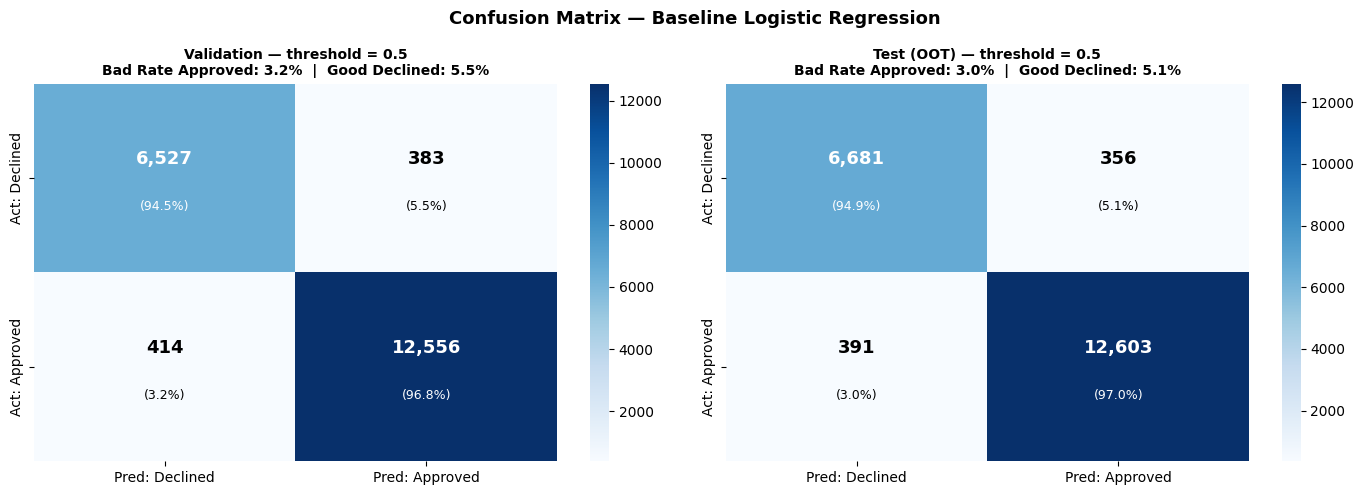


Validation Classification Report:
              precision    recall  f1-score   support

    Declined       0.94      0.94      0.94      6910
    Approved       0.97      0.97      0.97     12970

    accuracy                           0.96     19880
   macro avg       0.96      0.96      0.96     19880
weighted avg       0.96      0.96      0.96     19880



In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_true, y_pred, y_prob) in zip(axes, [
    ('Validation', y_val, y_val_pred, y_val_prob),
    ('Test (OOT)', y_test, y_test_pred, y_test_prob),
]):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Declined', 'Pred: Approved'],
                yticklabels=['Act: Declined', 'Act: Approved'])

    # Annotate with count and row %
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.4, f'{cm[i,j]:,}',
                    ha='center', va='center', fontsize=13, fontweight='bold', color='white' if cm[i,j] > cm.max()/2 else 'black')
            ax.text(j + 0.5, i + 0.65, f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=9, color='white' if cm[i,j] > cm.max()/2 else 'black')

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{name} — threshold = 0.5\n'
        f'Bad Rate Approved: {fn/(fn+tp)*100:.1f}%  |  Good Declined: {fp/(fp+tn)*100:.1f}%',
        fontsize=10, fontweight='bold'
    )

plt.suptitle('Confusion Matrix — Baseline Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Declined', 'Approved']))

## 5. ROC Curve & AUC

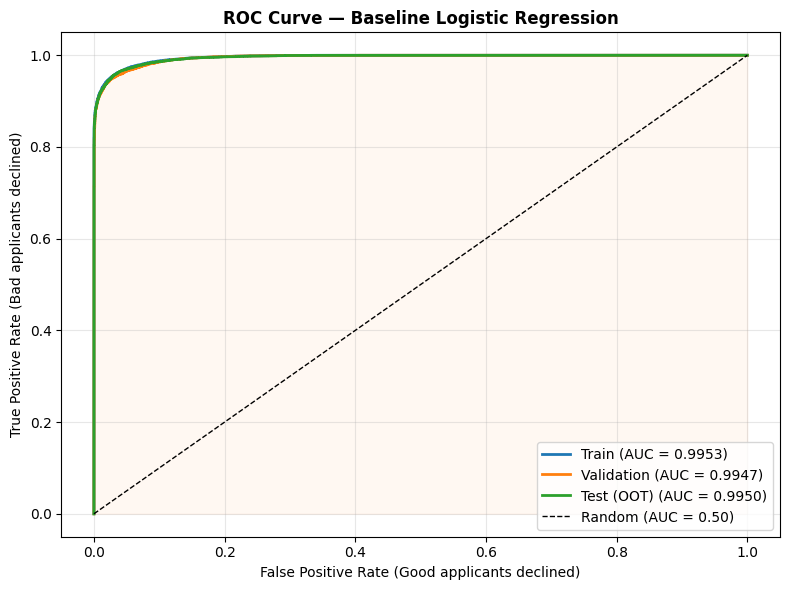

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_true, y_prob, color in [
    ('Train',      y_train, y_train_prob, '#1f77b4'),
    ('Validation', y_val,   y_val_prob,   '#ff7f0e'),
    ('Test (OOT)', y_test,  y_test_prob,  '#2ca02c'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
ax.fill_between(*roc_curve(y_val, y_val_prob)[:2], alpha=0.05, color='#ff7f0e')
ax.set_xlabel('False Positive Rate (Good applicants declined)')
ax.set_ylabel('True Positive Rate (Bad applicants declined)')
ax.set_title('ROC Curve — Baseline Logistic Regression', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. KS Statistic — Score Separation

The KS chart shows cumulative distributions of approval scores for actual good (approved) and bad (declined) applicants. The KS statistic is the maximum vertical gap between the two curves — the wider the gap, the better the model separates risk.

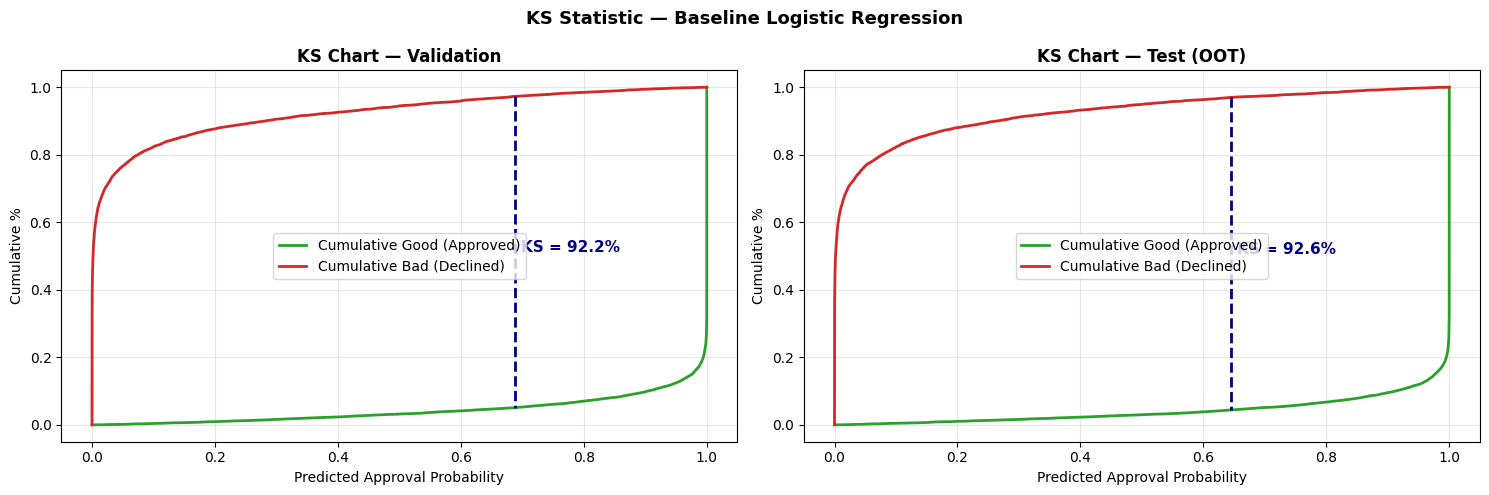

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (name, y_true, y_prob) in zip(axes, [
    ('Validation', y_val, y_val_prob),
    ('Test (OOT)', y_test, y_test_prob),
]):
    # Sort by predicted probability
    df_ks = pd.DataFrame({'prob': y_prob, 'actual': y_true}).sort_values('prob')

    n_good = (y_true == 1).sum()
    n_bad  = (y_true == 0).sum()

    # Cumulative distributions
    df_ks['cuml_good'] = (df_ks['actual'] == 1).cumsum() / n_good
    df_ks['cuml_bad']  = (df_ks['actual'] == 0).cumsum() / n_bad

    ks_val, ks_thresh = ks_statistic(y_true, y_prob)
    ks_idx = (df_ks['cuml_good'] - df_ks['cuml_bad']).abs().idxmax()
    ax.plot(df_ks['prob'], df_ks['cuml_good'], label='Cumulative Good (Approved)', color='#2ca02c', linewidth=2)
    ax.plot(df_ks['prob'], df_ks['cuml_bad'],  label='Cumulative Bad (Declined)',  color='#d62728', linewidth=2)

    # KS annotation
    ax.vlines(df_ks.loc[ks_idx, 'prob'],
              df_ks.loc[ks_idx, 'cuml_bad'],
              df_ks.loc[ks_idx, 'cuml_good'],
              colors='navy', linestyles='dashed', linewidth=2)
    ax.text(df_ks.loc[ks_idx, 'prob'] + 0.01,
            (df_ks.loc[ks_idx, 'cuml_bad'] + df_ks.loc[ks_idx, 'cuml_good']) / 2,
            f'KS = {ks_val:.1f}%', fontsize=11, color='navy', fontweight='bold')

    ax.set_xlabel('Predicted Approval Probability')
    ax.set_ylabel('Cumulative %')
    ax.set_title(f'KS Chart — {name}', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('KS Statistic — Baseline Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Precision-Recall Curve

Because approving a bad applicant costs more than declining a good one, the operating point on this curve is a business decision. The curve shows every possible trade-off between **bad rate accepted** (1 - Precision) and **good customer capture** (Recall).

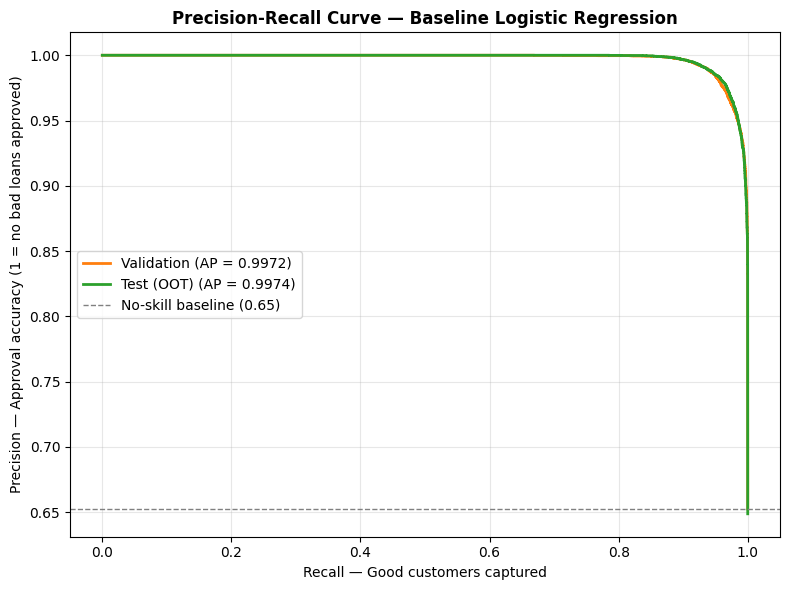

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_true, y_prob, color in [
    ('Validation', y_val,  y_val_prob,  '#ff7f0e'),
    ('Test (OOT)', y_test, y_test_prob, '#2ca02c'),
]:
    prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax.plot(rec, prec, label=f'{name} (AP = {ap:.4f})', color=color, linewidth=2)

# No-skill baseline = approval rate in test set
no_skill = y_val.mean()
ax.axhline(no_skill, linestyle='--', color='grey', linewidth=1, label=f'No-skill baseline ({no_skill:.2f})')

ax.set_xlabel('Recall — Good customers captured')
ax.set_ylabel('Precision — Approval accuracy (1 = no bad loans approved)')
ax.set_title('Precision-Recall Curve — Baseline Logistic Regression', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Gain & Lift Charts

Gain charts answer: *if we approve the top X% of scored applicants, what fraction of all genuine good applicants do we capture?*

Lift = Gain / Random. A lift of 1.5 at decile 4 means the model finds 50% more good applicants than random selection would in the same population slice.

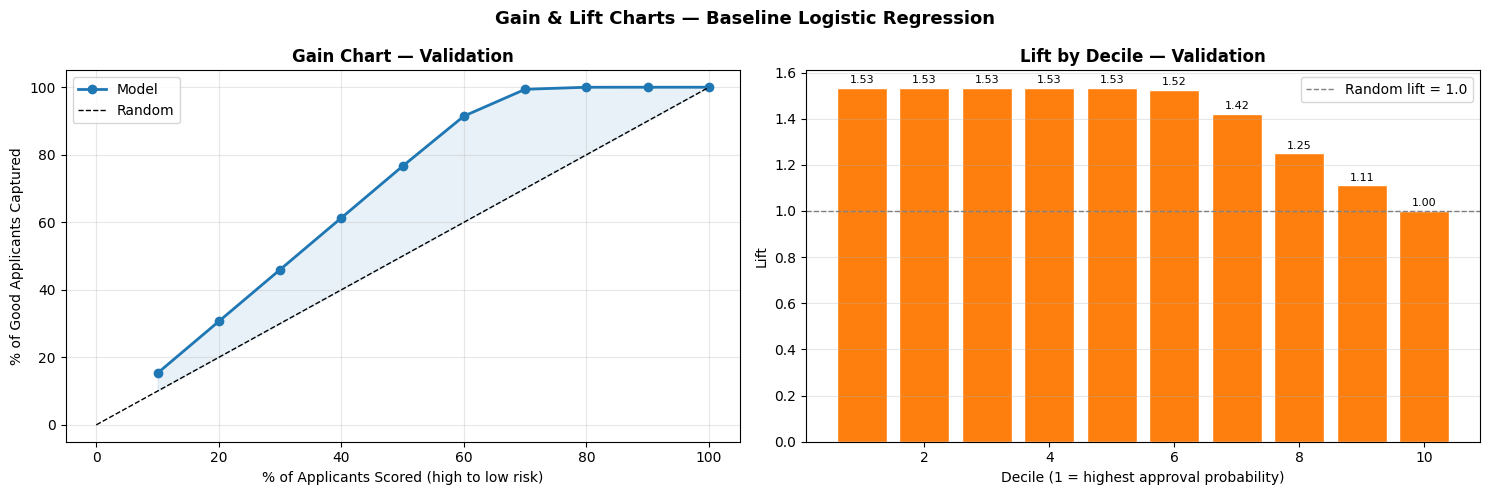

In [54]:
def gain_lift(y_true, y_prob, n_deciles=10):
    df = pd.DataFrame({'prob': y_prob, 'actual': y_true})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)
    df['decile'] = pd.qcut(df.index, q=n_deciles, labels=False) + 1

    total_good = y_true.sum()
    summary = df.groupby('decile').agg(
        n=('actual', 'count'),
        good=('actual', 'sum')
    ).reset_index()
    summary['cum_good']   = summary['good'].cumsum()
    summary['cum_pct']    = summary['decile'] / n_deciles * 100
    summary['gain']       = summary['cum_good'] / total_good * 100
    summary['lift']       = summary['gain'] / summary['cum_pct']
    return summary

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax_gain, ax_lift, (name, y_true, y_prob) in zip(
    [axes[0]], [axes[1]],
    [('Validation', y_val, y_val_prob)]
):
    gl = gain_lift(y_true, y_prob)

    # Gain chart
    ax_gain.plot(gl['cum_pct'], gl['gain'], marker='o', linewidth=2, color='#1f77b4', label='Model')
    ax_gain.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random')
    ax_gain.fill_between(gl['cum_pct'], gl['gain'], gl['cum_pct'], alpha=0.1, color='#1f77b4')
    ax_gain.set_xlabel('% of Applicants Scored (high to low risk)')
    ax_gain.set_ylabel('% of Good Applicants Captured')
    ax_gain.set_title(f'Gain Chart — {name}', fontweight='bold')
    ax_gain.legend()
    ax_gain.grid(alpha=0.3)

    # Lift chart
    ax_lift.bar(gl['decile'], gl['lift'], color='#ff7f0e', edgecolor='white')
    ax_lift.axhline(1.0, color='grey', linestyle='--', linewidth=1, label='Random lift = 1.0')
    for _, row in gl.iterrows():
        ax_lift.text(row['decile'], row['lift'] + 0.02, f"{row['lift']:.2f}",
                     ha='center', fontsize=8)
    ax_lift.set_xlabel('Decile (1 = highest approval probability)')
    ax_lift.set_ylabel('Lift')
    ax_lift.set_title(f'Lift by Decile — {name}', fontweight='bold')
    ax_lift.legend()
    ax_lift.grid(alpha=0.3, axis='y')

plt.suptitle('Gain & Lift Charts — Baseline Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Calibration Curve

A well-calibrated model means *if the model assigns a 70% approval probability, roughly 70% of those applicants should actually be good*. Calibration matters if probabilities are used directly for pricing, loss provisioning, or setting tiered credit limits.

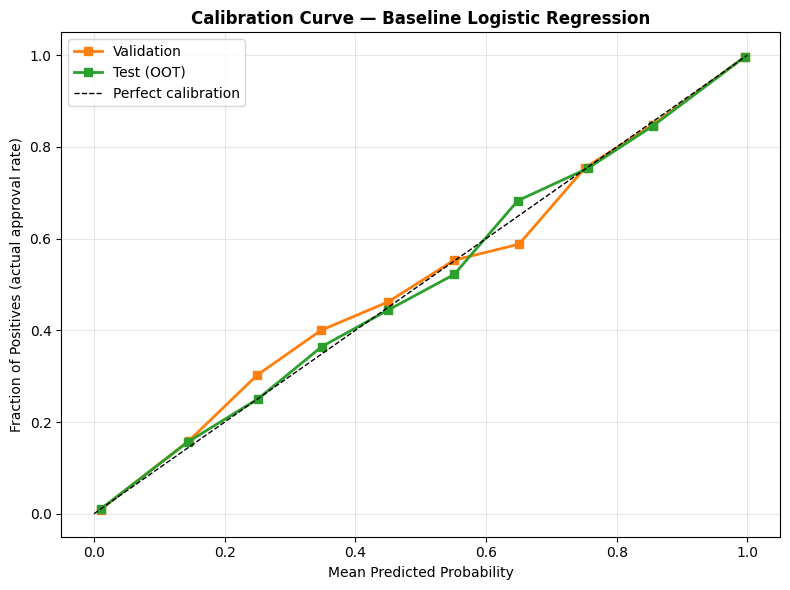

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_true, y_prob, color in [
    ('Validation', y_val,  y_val_prob,  '#ff7f0e'),
    ('Test (OOT)', y_test, y_test_prob, '#2ca02c'),
]:
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='s', linewidth=2, color=color, label=name)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (actual approval rate)')
ax.set_title('Calibration Curve — Baseline Logistic Regression', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Top Feature Coefficients

Logistic regression coefficients are directly interpretable as the log-odds contribution of each feature. Positive coefficients increase approval probability; negative coefficients decrease it. This is what makes logistic regression the regulatory default — every model decision can be traced to a specific feature and its weight.

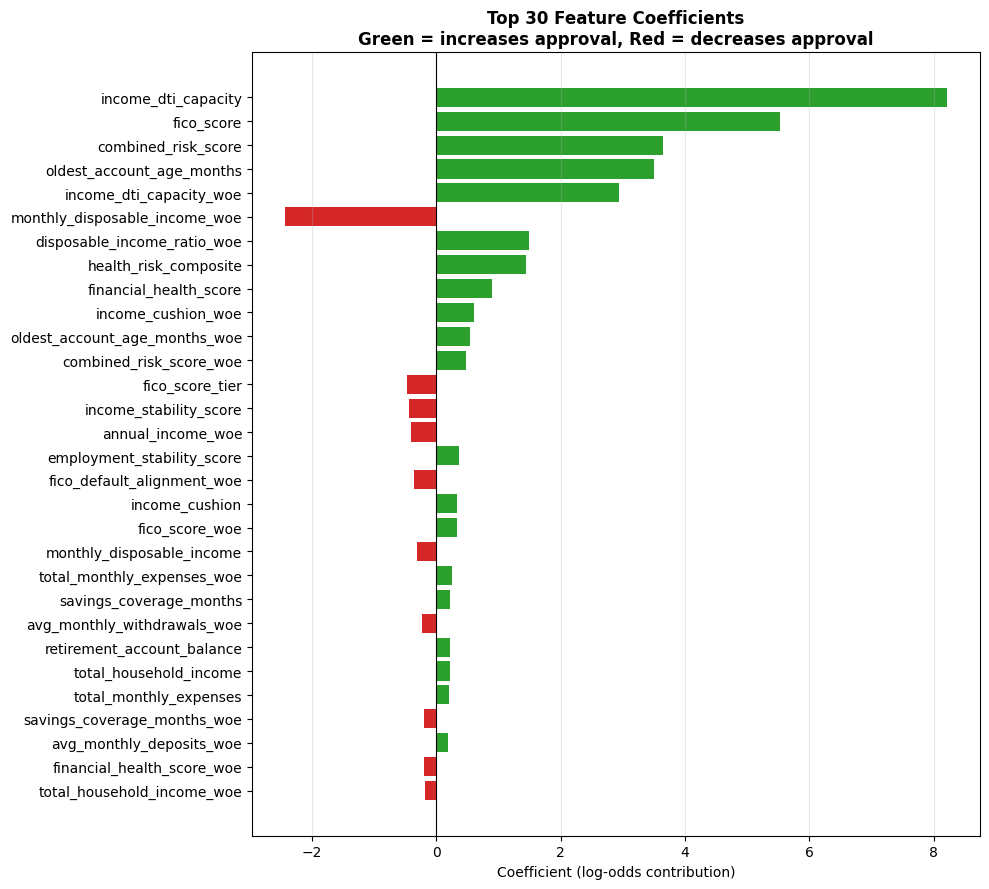

In [56]:
coef_df = pd.DataFrame({
    'feature':     X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#2ca02c' if c > 0 else '#d62728' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds contribution)')
ax.set_title('Top 30 Feature Coefficients\nGreen = increases approval, Red = decreases approval',
             fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 11. Performance Summary & Train vs OOT Gap

The gap between validation and OOT test performance is the key stability indicator. A large gap (>5 Gini points) suggests the model is sensitive to temporal drift and may need retraining more frequently in production.

In [57]:
summary_df = pd.DataFrame(results)
summary_df = summary_df.set_index('name')
summary_df['gini'] = summary_df['gini'].map('{:.4f}'.format)
summary_df['auc']  = summary_df['auc'].map('{:.4f}'.format)
summary_df['ks']   = summary_df['ks'].map('{:.2f}%'.format)
summary_df['brier']= summary_df['brier'].map('{:.4f}'.format)
summary_df['avg_precision'] = summary_df['avg_precision'].map('{:.4f}'.format)

print("=" * 65)
print("BASELINE LOGISTIC REGRESSION — PERFORMANCE SUMMARY")
print("=" * 65)
print(summary_df.to_string())

# Train vs OOT Gini gap
train_gini = float(results[0]['gini'])
oot_gini   = float(results[2]['gini'])
gap        = train_gini - oot_gini
print(f"\nTrain → OOT Gini gap: {gap:.4f} ({'⚠ notable drift' if gap > 0.05 else '✅ stable'})")
print(f"Train → OOT KS gap:   {results[0]['ks'] - results[2]['ks']:.2f}%")

BASELINE LOGISTIC REGRESSION — PERFORMANCE SUMMARY
               auc    gini      ks avg_precision   brier
name                                                    
Train       0.9953  0.9906  92.68%        0.9975  0.0260
Validation  0.9947  0.9894  92.22%        0.9972  0.0278
Test (OOT)  0.9950  0.9900  92.65%        0.9974  0.0268

Train → OOT Gini gap: 0.0006 (✅ stable)
Train → OOT KS gap:   0.03%


In [58]:
joblib.dump(lr,     '../models/baseline_logistic_regression.pkl')
joblib.dump(scaler, '../models/baseline_scaler.pkl')

print("Saved:")
print("  models/baseline_logistic_regression.pkl")
print("  models/baseline_scaler.pkl")

Saved:
  models/baseline_logistic_regression.pkl
  models/baseline_scaler.pkl
